
## End-to-End EDA Pipeline

This notebook demonstrates a complete EDA workflow:
- Data inspection
- Cleaning
- EDA
- Leakage detection
- ML readiness checks

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## Create Raw Dataset (Simulating Production Data)

In [2]:

raw_data = {
    "customer_id": [1,2,3,4,5,6,7,8,9],
    "age": [25, 30, None, 45, 200, 35, 40, None, 28],
    "category": ["A", "B", "A", "C", "B", "C", "C", "A", "B"],
    "tenure_months": [2, 5, 8, 12, 1, 36, 48, 3, 6],
    "monthly_spend": [100, 150, 120, 200, 3000, 180, 220, 130, 160],
    "total_spend": [200, 750, 960, 2400, 3000, 6480, 10560, 390, 960],
    "churn": [1, 0, 0, 0, 1, 0, 0, 1, 0]
}

df = pd.DataFrame(raw_data)
df


,customer_id,age,category,tenure_months,monthly_spend,total_spend,churn
0,1,25.0,A,2,100,200,1
1,2,30.0,B,5,150,750,0
2,3,NaN,A,8,120,960,0
3,4,45.0,C,12,200,2400,0
4,5,200.0,B,1,3000,3000,1
5,6,35.0,C,36,180,6480,0
6,7,40.0,C,48,220,10560,0
7,8,NaN,A,3,130,390,1
8,9,28.0,B,6,160,960,0


## Initial Inspection

In [3]:

df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    9 non-null      int64  
 1   age            7 non-null      float64
 2   category       9 non-null      object 
 3   tenure_months  9 non-null      int64  
 4   monthly_spend  9 non-null      int64  
 5   total_spend    9 non-null      int64  
 6   churn          9 non-null      int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 636.0+ bytes


customer_id      0
age              2
category         0
tenure_months    0
monthly_spend    0
total_spend      0
churn            0
dtype: int64

## Data Cleaning

In [4]:

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["age"] = df["age"].fillna(df["age"].median())
df.loc[df["age"] > 100, "age"] = df["age"].median()

Q1 = df["monthly_spend"].quantile(0.25)
Q3 = df["monthly_spend"].quantile(0.75)
IQR = Q3 - Q1

df["monthly_spend"] = df["monthly_spend"].clip(
    lower=Q1 - 1.5 * IQR,
    upper=Q3 + 1.5 * IQR
)

df


,customer_id,age,category,tenure_months,monthly_spend,total_spend,churn
0,1,25.0,A,2,100,200,1
1,2,30.0,B,5,150,750,0
2,3,35.0,A,8,120,960,0
3,4,45.0,C,12,200,2400,0
4,5,35.0,B,1,305,3000,1
5,6,35.0,C,36,180,6480,0
6,7,40.0,C,48,220,10560,0
7,8,35.0,A,3,130,390,1
8,9,28.0,B,6,160,960,0


## Distribution Analysis

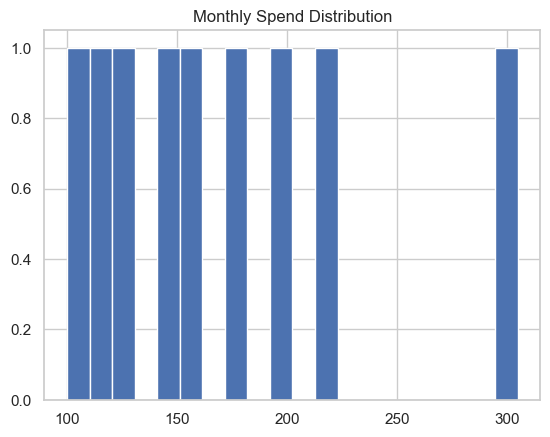

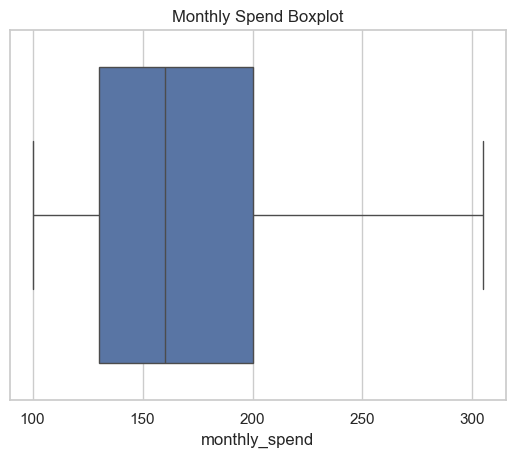

In [5]:

df["monthly_spend"].hist(bins=20)
plt.title("Monthly Spend Distribution")
plt.show()

sns.boxplot(x=df["monthly_spend"])
plt.title("Monthly Spend Boxplot")
plt.show()


## Categorical Analysis

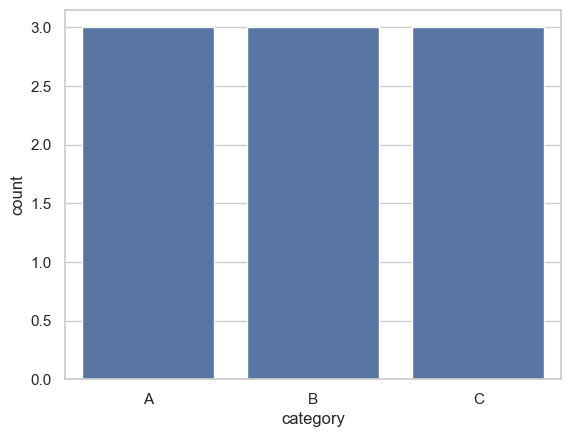

In [6]:

df["category"].value_counts(normalize=True) * 100

sns.countplot(data=df, x="category")
plt.show()


## Feature vs Target Analysis

In [7]:

df.groupby("churn")["monthly_spend"].mean()

pd.crosstab(df["category"], df["churn"], normalize="index")


churn,0,1
category,,
A,0.333333,0.666667
B,0.666667,0.333333
C,1.000000,0.000000


## Correlation & Leakage Check

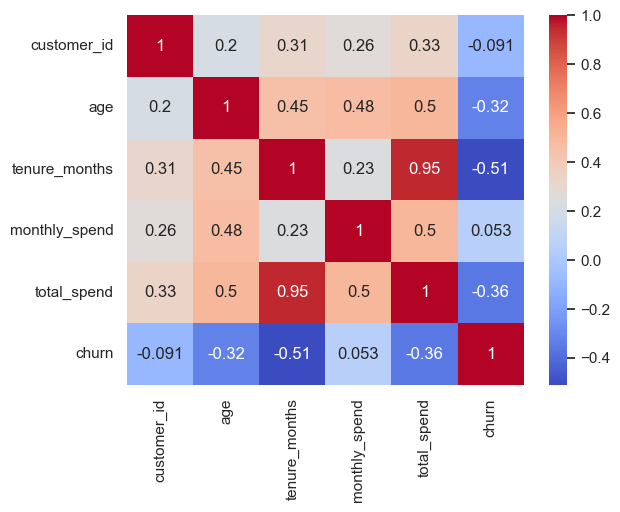

churn            1.000000
monthly_spend    0.053471
customer_id     -0.091287
age             -0.316407
total_spend     -0.356434
tenure_months   -0.511105
Name: churn, dtype: float64

In [8]:

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

corr["churn"].sort_values(ascending=False)


## Remove Leakage & Final Validation

In [9]:

df = df.drop(columns=["total_spend"])

df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    9 non-null      int64  
 1   age            9 non-null      float64
 2   category       9 non-null      object 
 3   tenure_months  9 non-null      int64  
 4   monthly_spend  9 non-null      int64  
 5   churn          9 non-null      int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 564.0+ bytes


customer_id      0
age              0
category         0
tenure_months    0
monthly_spend    0
churn            0
dtype: int64

## Final Notes
This dataset is now cleaned, explored, and validated for ML readiness.